<a href="https://colab.research.google.com/github/nomanpathan485/-231A020-_NLP_EXPERIMENTS/blob/main/NLP10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Name: Noman pathan
# UIN: 231A020
# Experiment 10: Exploratory Data Analysis on Text

!pip install -q wordcloud

import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

student = "Noman pathan | UIN: 231A020"
print(student)
print("Libraries imported successfully.")

Noman pathan | UIN: 231A020
Libraries imported successfully.


In [11]:
# Name: Noman pathan
# UIN: 231A020

corpus = [
    "The product is good and the quality is excellent.",
    "The service is good and the delivery is fast.",
    "The product quality is poor and the delivery is slow.",
    "The product is excellent and the service is good.",
    "The delivery is fast and the product is good."
]

print(student)
print("Number of reviews:", len(corpus))

for number, review in enumerate(corpus, start=1):
    print(f"{number}. {review}")

Noman pathan | UIN: 231A020
Number of reviews: 5
1. The product is good and the quality is excellent.
2. The service is good and the delivery is fast.
3. The product quality is poor and the delivery is slow.
4. The product is excellent and the service is good.
5. The delivery is fast and the product is good.


In [12]:
# Name: Noman pathan
# UIN: 231A020

# Small stop word list for this demonstration.
stop_words = {"the", "is", "and", "a", "an", "of", "to", "in"}

# Keep tokens separated by review for later bigram analysis.
tokens_by_review = [
    re.findall(r"\b[a-z]+\b", review.lower())
    for review in corpus
]

tokens = [
    word
    for review_tokens in tokens_by_review
    for word in review_tokens
]

cleaned_tokens = [
    word for word in tokens
    if word not in stop_words
]

print(student)
print("Original tokens:", tokens)
print("\nAfter stop word removal:", cleaned_tokens)
print("\nOriginal word count:", len(tokens))
print("Cleaned word count:", len(cleaned_tokens))

Noman pathan | UIN: 231A020
Original tokens: ['the', 'product', 'is', 'good', 'and', 'the', 'quality', 'is', 'excellent', 'the', 'service', 'is', 'good', 'and', 'the', 'delivery', 'is', 'fast', 'the', 'product', 'quality', 'is', 'poor', 'and', 'the', 'delivery', 'is', 'slow', 'the', 'product', 'is', 'excellent', 'and', 'the', 'service', 'is', 'good', 'the', 'delivery', 'is', 'fast', 'and', 'the', 'product', 'is', 'good']

After stop word removal: ['product', 'good', 'quality', 'excellent', 'service', 'good', 'delivery', 'fast', 'product', 'quality', 'poor', 'delivery', 'slow', 'product', 'excellent', 'service', 'good', 'delivery', 'fast', 'product', 'good']

Original word count: 46
Cleaned word count: 21


In [13]:
# Name: Noman pathan
# UIN: 231A020

word_frequency = Counter(cleaned_tokens)

# Count adjacent word pairs within each original review.
# Exclude pairs containing stop words.
bigrams = []

for review_tokens in tokens_by_review:
    for first, second in zip(review_tokens, review_tokens[1:]):
        if first not in stop_words and second not in stop_words:
            bigrams.append((first, second))

bigram_frequency = Counter(bigrams)

print(student)
print("\nWord frequencies:")

for word, count in word_frequency.most_common():
    print(f"{word}: {count}")

print("\nMost common bigrams:")

for pair, count in bigram_frequency.most_common(5):
    print(f"{pair[0]} {pair[1]}: {count}")

Noman pathan | UIN: 231A020

Word frequencies:
product: 4
good: 4
delivery: 3
quality: 2
excellent: 2
service: 2
fast: 2
poor: 1
slow: 1

Most common bigrams:
product quality: 1


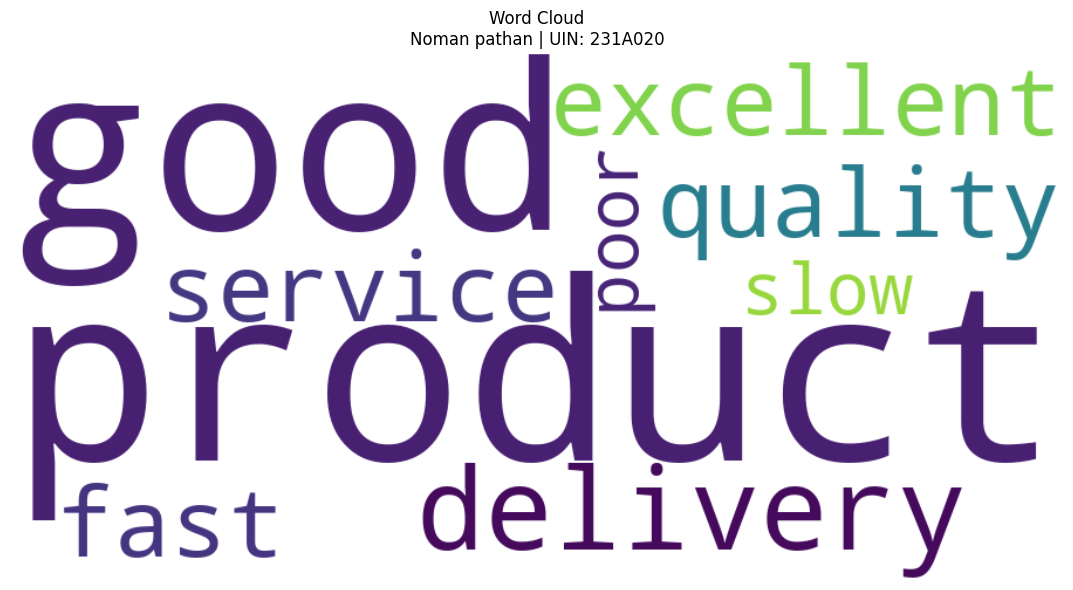

In [14]:
# Name: Noman pathan
# UIN: 231A020

cloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    colormap="viridis",
    random_state=42
).generate_from_frequencies(word_frequency)

plt.figure(figsize=(12, 6))
plt.imshow(cloud, interpolation="bilinear")
plt.title(f"Word Cloud\n{student}")
plt.axis("off")
plt.tight_layout()
plt.show()

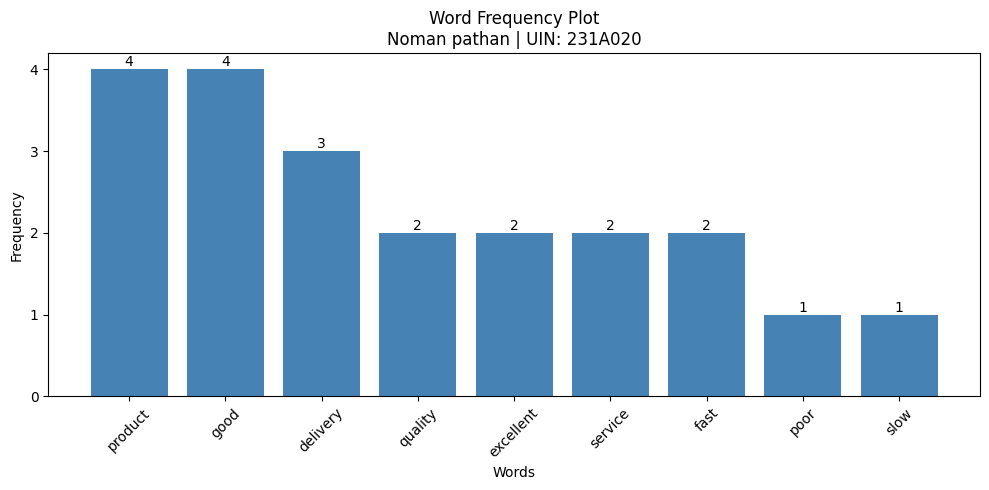

In [15]:
# Name: Noman pathan
# UIN: 231A020

common_words = word_frequency.most_common(10)
words = [word for word, count in common_words]
counts = [count for word, count in common_words]

plt.figure(figsize=(10, 5))
bars = plt.bar(words, counts, color="steelblue")
plt.bar_label(bars)

plt.title(f"Word Frequency Plot\n{student}")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.yticks(range(max(counts) + 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

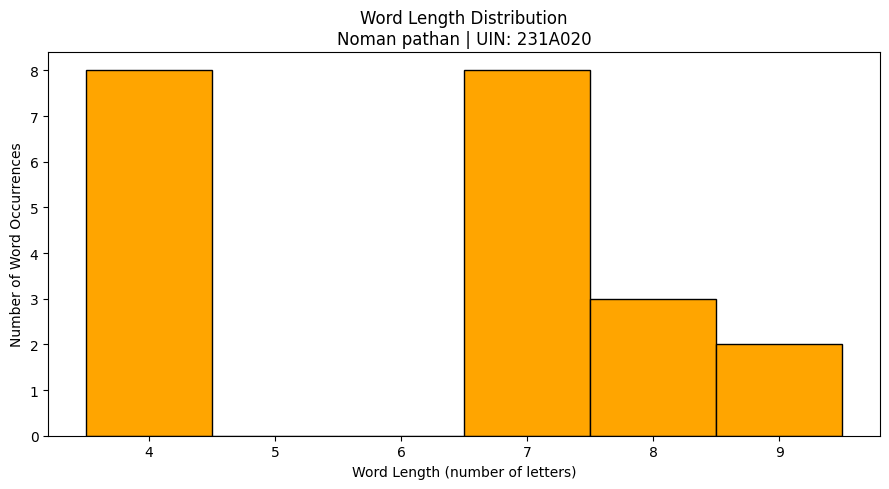

Noman pathan | UIN: 231A020
Average word length: 6.19


In [16]:
# Name: Noman pathan
# UIN: 231A020

word_lengths = [len(word) for word in cleaned_tokens]

# Center histogram bins on integer word lengths.
bins = [
    length - 0.5
    for length in range(min(word_lengths), max(word_lengths) + 2)
]

plt.figure(figsize=(9, 5))
plt.hist(
    word_lengths,
    bins=bins,
    color="orange",
    edgecolor="black"
)

plt.title(f"Word Length Distribution\n{student}")
plt.xlabel("Word Length (number of letters)")
plt.ylabel("Number of Word Occurrences")
plt.xticks(range(min(word_lengths), max(word_lengths) + 1))
plt.tight_layout()
plt.show()

print(student)
print("Average word length:", round(
    sum(word_lengths) / len(word_lengths), 2
))